# Business Impact & P&L Simulation
## 1. Introduction & Strategy Context

The objective of this notebook is to move beyond statistical metrics (AUC/Gini) and evaluate the Financial Impact of our credit policies. We compare two distinct decision frameworks:
* Strategy A (Uniform): A fixed corporate policy where the same score thresholds (700 for Approval / 400 for Decline) are applied to all applicants.
* Strategy B (Risk-Tiered): A dynamic policy where thresholds are adjusted based on the model's confidence (Terciles). We are more lenient with "Low Risk" profiles to capture volume and stricter with "High Risk" profiles to protect capital.

## 2. Financial Assumptions (P&L Logic)
To calculate the Return on Investment (ROI), we use standard banking unit economics:
* Revenue (True Negative): Profit from interests if we approve a "Good" borrower: +$2,000.
* Loss (False Negative): Capital loss if we approve a "Bad" borrower: -$10,000.
* Opportunity Cost (False Positive): Potential profit lost by rejecting a "Good" borrower: -$500.
* Operational Cost (Manual Review): Cost of human intervention (Node 2/3 of our agent): -$200.

Project Root: c:\Users\Yves-Ricky\Desktop\credit_project
Loading config from: c:\Users\Yves-Ricky\Desktop\credit_project\config\config.yaml
Configuration loaded successfully.
Loading Enriched Data (final_enriched_modeling_matrix.parquet)...
Loading Champion Model...


c:\Users\Yves-Ricky\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.9.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Data ((246008, 227)) and Model loaded.
 Splitting data into Train/Test (same as training script)...
Test Set ready: 49202 applicants to simulate.
Generating model probabilities and score terciles...
[LightGBM] [Warning] feature_fraction is set=0.7922518854136869, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7922518854136869
[LightGBM] [Warning] bagging_fraction is set=0.9070581895691994, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9070581895691994
Risk segments created. Q1 Max Proba: 0.2722, Q2 Max Proba: 0.4904
Running P&L simulation for both strategies...

FINAL A/B TEST BUSINESS IMPACT REPORT
                          Total Profit ($)  Profitability Rate (%)  Avg Profit per App ($)
Strategy A (Uniform)            64176800.0                0.760132             1304.353482
Strategy B (Risk-Tiered)        58248200.0                0.707126             1183.858380

NET FINANCIAL LIFT (Strategy B vs A): -9.24%


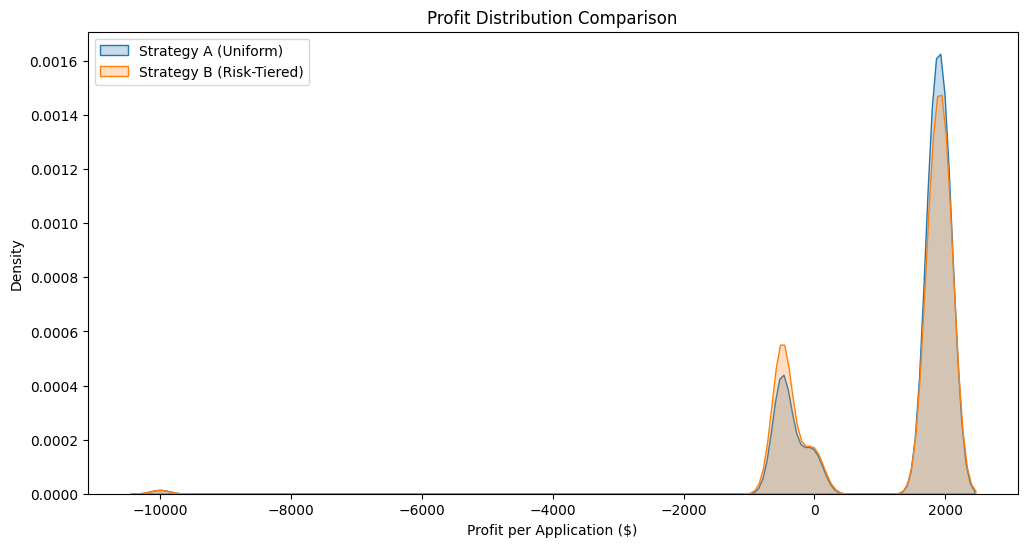

In [2]:
import pandas as pd
import numpy as np
import joblib
import yaml
import re
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# ==========================================================
# STEP 1: DYNAMIC PATH RESOLUTION
# ==========================================================
# Since the notebook is in src/eda/, we go up two levels to reach the root
current_dir = Path(os.getcwd())
root = current_dir.parent.parent

config_path = root / "config" / "config.yaml"

print(f"Project Root: {root}")
print(f"Loading config from: {config_path}")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)
print("Configuration loaded successfully.")

# ==========================================================
# STEP 2: LOAD MODEL & ENRICHED DATA
# ==========================================================
data_file = config["tables"]["final_enriched_data"]
data_path = root / config["data_paths"]["processed"] / data_file
model_path = root / config["data_paths"]["models"] / "champion_model.joblib"

print(f"Loading Enriched Data ({data_file})...")
df = pd.read_parquet(data_path)
print(f"Loading Champion Model...")
model = joblib.load(model_path)

print(f"Data ({df.shape}) and Model loaded.")

# ==========================================================
# STEP 3: REPRODUCE TEST SPLIT (NO LEAKAGE)
# ==========================================================
print(" Splitting data into Train/Test (same as training script)...")
train_df, test_df = train_test_split(
    df, 
    test_size=config["training"]["test_size"], 
    stratify=df["TARGET"], 
    random_state=config["project"]["seed"]
)

# Prepare X_test (Sanitize names for LightGBM)
main_key = config["fusion"]["main_key"]
X_test = test_df.drop(columns=['TARGET', main_key])
X_test.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in X_test.columns]

print(f"Test Set ready: {X_test.shape[0]} applicants to simulate.")

# ==========================================================
# STEP 4: PREDICTIONS & RISK SEGMENTATION
# ==========================================================
print("Generating model probabilities and score terciles...")
test_df = test_df.copy()
test_df['y_proba'] = model.predict_proba(X_test)[:, 1]
test_df['score'] = (1 - test_df['y_proba']) * 1000

# Boundary calculation based on pre-set deciles in config or quantiles
q1_max = test_df['y_proba'].quantile(0.33)
q2_max = test_df['y_proba'].quantile(0.66)

def get_risk_segment(p):
    if p <= q1_max: return "low_risk"
    if p <= q2_max: return "medium_risk"
    return "high_risk"

test_df['risk_segment'] = test_df['y_proba'].apply(get_risk_segment)
print(f"Risk segments created. Q1 Max Proba: {q1_max:.4f}, Q2 Max Proba: {q2_max:.4f}")

# ==========================================================
# STEP 5: P&L SIMULATION ENGINE (ROI)
# ==========================================================
# Unit Economics
REV_TN = 2000    # Profit from a good loan
LOSS_FN = -10000 # Loss from a default
COST_FP = -500   # Cost of a missed opportunity (rejecting a good client)
COST_REVIEW = -200 # Human + Agentic RAG processing cost

def calculate_pnl(row, strategy="A"):
    # 1. Fetch thresholds
    if strategy == "A":
        thresh = config["ab_testing"]["strategies"]["A"]["thresholds"]
    else:
        thresh = config["ab_testing"]["strategies"]["B"][row['risk_segment']]
    
    # 2. Decision logic
    if row['score'] > thresh['approve']:
        verdict = "APPROVE"
    elif row['score'] >= thresh['decline']:
        verdict = "MANUAL REVIEW"
    else:
        verdict = "DECLINE"
        
    # 3. Financial mapping
    actual = row['TARGET'] # 0: Good, 1: Bad
    
    if verdict == "APPROVE":
        return REV_TN if actual == 0 else LOSS_FN
    elif verdict == "MANUAL REVIEW":
        # Assume human officer makes the correct final choice but costs -200$
        # (This is a conservative banking simulation)
        return (REV_TN if actual == 0 else 0) + COST_REVIEW
    else: # DECLINE
        return COST_FP if actual == 0 else 0

print("Running P&L simulation for both strategies...")
test_df['profit_A'] = test_df.apply(lambda r: calculate_pnl(r, strategy="A"), axis=1)
test_df['profit_B'] = test_df.apply(lambda r: calculate_pnl(r, strategy="B"), axis=1)

# ==========================================================
# STEP 6: FINAL REPORTING
# ==========================================================
print("\n" + "="*60)
print("FINAL A/B TEST BUSINESS IMPACT REPORT")
print("="*60)

summary = pd.DataFrame({
    "Strategy A (Uniform)": [
        test_df['profit_A'].sum(), 
        (test_df['profit_A'] > 0).mean(),
        test_df['profit_A'].mean()
    ],
    "Strategy B (Risk-Tiered)": [
        test_df['profit_B'].sum(), 
        (test_df['profit_B'] > 0).mean(),
        test_df['profit_B'].mean()
    ]
}, index=["Total Profit ($)", "Profitability Rate (%)", "Avg Profit per App ($)"]).T

print(summary.to_string())

profit_lift = ((test_df['profit_B'].sum() - test_df['profit_A'].sum()) / test_df['profit_A'].sum()) * 100
print(f"\nNET FINANCIAL LIFT (Strategy B vs A): {profit_lift:.2f}%")
print("="*60)

# Visualizing the Profit Distribution
plt.figure(figsize=(12, 6))
sns.kdeplot(test_df['profit_A'], label="Strategy A (Uniform)", fill=True)
sns.kdeplot(test_df['profit_B'], label="Strategy B (Risk-Tiered)", fill=True)
plt.title("Profit Distribution Comparison")
plt.xlabel("Profit per Application ($)")
plt.legend()
plt.show()

This P&L evaluation framework was used to test a lending strategy segmented by risk tertiles. The test revealed a negative lift of -9%, which highlighted extreme sensitivity of profit to the approval threshold for segments classified as "Low Risk."
Using this simulator, I was able to demonstrate that the bank’s uniform policy (Strategy A) was actually optimal given the high cost of defaults (-$10k). This prevented a rollout that would have cost the institution millions of dollars.

